# Nhiệm vụ 7 — Chất lượng cụm PCA + K-Means

Chỉ phân tích `diagnostics.csv` của nhiệm vụ 6, không fit lại.
Lọc K=2 trên đúng 15 development snapshots; xuất **duy nhất một CSV**
`M2/artifacts/m2-evaluation-pca-kmeans/quality_summary.csv` gồm 5 dòng × 7 cột.
Path v2 thay cho bản v1 sai schema; bản cũ được giữ làm evidence.
Metrics được đo trong không gian PCA 4 chiều thực sự dùng để clustering.
Silhouette là tiêu chí chính, Davies–Bouldin là xác nhận;
CH/Balance là kiểm định bổ sung. Không dùng lợi nhuận/Sharpe hoặc holdout.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Tìm root bằng file config, không phụ thuộc tên thư mục hoặc máy cá nhân.
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / 'configs/experiments/m2_task6_pca.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Chạy notebook từ repository hoặc M2/notebooks.')
sys.path.insert(0, str(ROOT / 'src'))
from delta_t1.experiments.protocol import validate_protocol
CONFIG = json.loads((ROOT / 'configs/experiments/m2_task6_pca.json').read_text(encoding='utf-8'))
validate_protocol(CONFIG)
FEATURES = CONFIG['clustering']['features']
DEV_DATES = CONFIG['development_snapshots']
K = CONFIG['clustering']['k']
TASK_DIR = ROOT / 'M2/artifacts/m2-task6-pca-kmeans-v1'
EVAL_DIR = ROOT / 'M2/artifacts/m2-evaluation-pca-kmeans'
REPORT_DIR = ROOT / 'M2/reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
print('Root:', ROOT)
print('Development:', DEV_DATES[0], '→', DEV_DATES[-1], '| Global K:', K)

def publish_csv(path, frame):
    content = frame.to_csv(index=False, lineterminator='\n').encode('utf-8')
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.read_bytes() != content:
        raise RuntimeError(f'CSV khác nội dung đã tồn tại: {path}; cần version mới.')
    if not path.exists():
        path.write_bytes(content)

def table_md(frame):
    def clean(value):
        return str(value).replace('|', '\\|').replace('\n', ' ')
    columns = frame.columns.tolist()
    lines = ['| ' + ' | '.join(map(clean, columns)) + ' |',
             '| ' + ' | '.join(['---'] * len(columns)) + ' |']
    for row in frame.itertuples(index=False, name=None):
        lines.append('| ' + ' | '.join(map(clean, row)) + ' |')
    return '\n'.join(lines)

Root: C:\Users\HOME\Desktop\M2\Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment
Development: 2023-11-30 → 2025-01-24 | Global K: 2


## 7.1–7.5 — Kiểm tra diagnostics và lọc Global K

In [2]:
# Fail-closed: chỉ đọc bộ v2 hoàn tất, có checksum và cùng config.
manifest = json.loads((TASK_DIR / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
assert manifest['config'] == CONFIG, 'Config thay đổi: cần run/version mới.'
for rel, expected in manifest['artifacts'].items():
    path = ROOT / rel
    assert hashlib.sha256(path.read_bytes()).hexdigest() == expected, f'Checksum mismatch: {rel}'

diag = pd.read_csv(TASK_DIR / 'diagnostics.csv')
required = ['snapshot_date', 'k', 'silhouette', 'davies_bouldin', 'calinski_harabasz',
            'inertia', 'cluster_balance', 'cluster_sizes', 'converged']
assert set(required).issubset(diag.columns)
assert not diag.duplicated(['snapshot_date', 'k']).any()
assert len(diag) == 105 and set(diag.k) == set(CONFIG['clustering']['k_range'])
df_k2 = diag[diag.k.eq(K)].sort_values('snapshot_date').reset_index(drop=True)
assert df_k2.snapshot_date.tolist() == DEV_DATES and len(df_k2) == 15
METRICS = ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'inertia', 'cluster_balance']
assert np.isfinite(df_k2[METRICS].to_numpy(float)).all()
assert df_k2.converged.astype(str).str.lower().eq('true').all()
sizes = df_k2.cluster_sizes.map(json.loads)
assert all(set(map(int, s)) == set(range(K)) and sum(s.values()) >= CONFIG['min_eligible_count']
           for s in sizes)
assert np.allclose(df_k2.cluster_balance, [min(s.values())/max(s.values()) for s in sizes])

## Bảng 1 — Tóm tắt chất lượng: 5 dòng × 7 cột

In [3]:
summary_df = pd.DataFrame([dict(metric=m, n_total=len(df_k2), n_available=int(df_k2[m].notna().sum()),
    mean=df_k2[m].mean(), median=df_k2[m].median(), minimum=df_k2[m].min(), maximum=df_k2[m].max())
    for m in METRICS])
assert summary_df.shape == (5, 7)
assert summary_df.columns.tolist() == ['metric', 'n_total', 'n_available', 'mean', 'median', 'minimum', 'maximum']
assert summary_df.n_available.eq(15).all()
display(summary_df.round(6))
publish_csv(EVAL_DIR / 'quality_summary.csv', summary_df)

,metric,n_total,n_available,mean,median,minimum,maximum
0,silhouette,15,15,0.804410,0.771666,0.659505,0.951234
1,davies_bouldin,15,15,0.499010,0.515502,0.354967,0.716695
2,calinski_harabasz,15,15,709.194537,361.527940,176.314178,2065.151594
3,inertia,15,15,53212.333977,1963.065124,1219.015572,328111.440073
4,cluster_balance,15,15,0.056407,0.067669,0.010363,0.094972


## Bảng 2 — Chi tiết chất lượng: 15 dòng × 6 cột

In [4]:
detail_df = df_k2[['snapshot_date', *METRICS]].rename(columns=dict(zip(
    ['snapshot_date', *METRICS], ['Snapshot', 'Silhouette', 'DB', 'CH', 'Inertia', 'Balance'])))
assert detail_df.shape == (15, 6)
display(detail_df.round(6))

,Snapshot,Silhouette,DB,CH,Inertia,Balance
0,2023-11-30,0.775353,0.536114,225.635234,1219.015572,0.067669
1,2023-12-29,0.771666,0.472406,417.106858,1267.010612,0.089385
2,2024-01-31,0.719430,0.558519,261.530664,1360.147611,0.094972
3,2024-02-29,0.745119,0.482618,361.527940,1295.238398,0.094972
4,2024-03-29,0.676387,0.590633,190.663829,1257.003284,0.082418
5,2024-04-26,0.728588,0.547559,261.893710,1535.166794,0.070000
6,2024-05-31,0.704280,0.573273,232.343692,1543.374428,0.072816
7,2024-06-28,0.763995,0.515502,274.715119,1963.065124,0.048035
8,2024-07-31,0.659505,0.716695,176.314178,2009.521186,0.073913
9,2024-08-30,0.906888,0.472977,926.687158,121106.779768,0.036585


## Năm biểu đồ chuẩn

Median nét đứt đỏ; Balance thêm ngưỡng 0,05 màu đỏ đậm.
Inertia chịu ảnh hưởng cả quy mô N và độ phân tán dữ liệu;
không dùng biến thiên Inertia để tự xếp hạng chất lượng giữa các tháng.

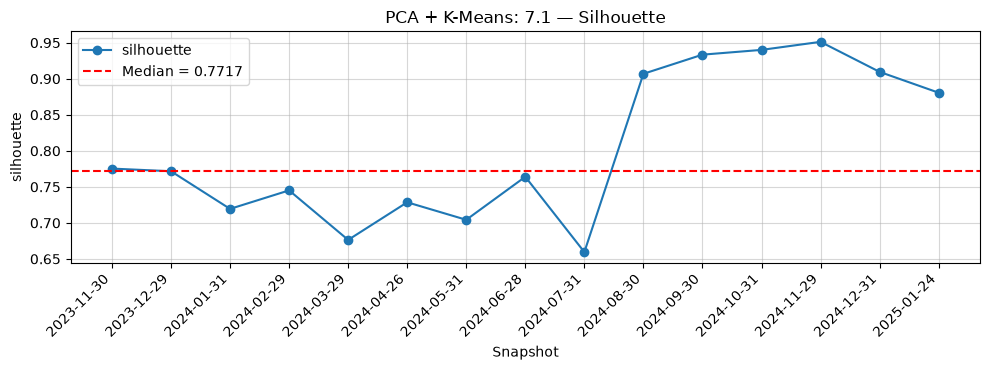

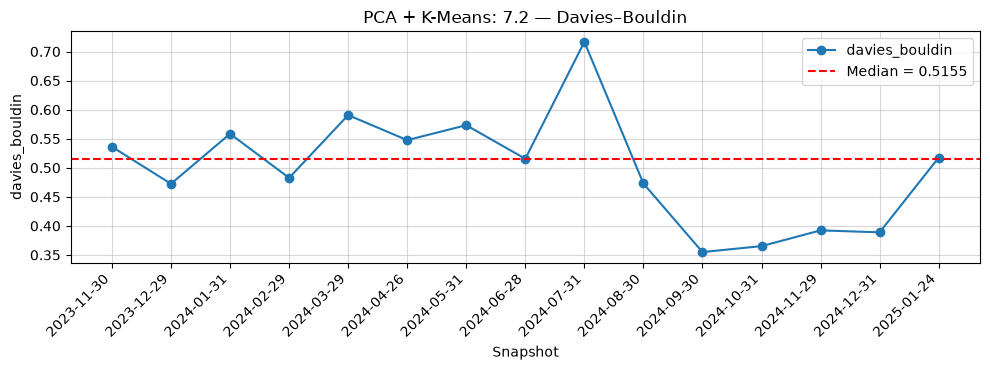

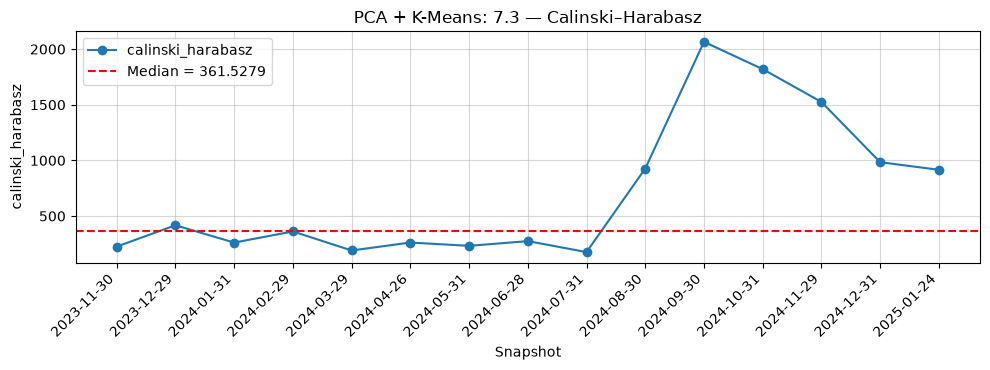

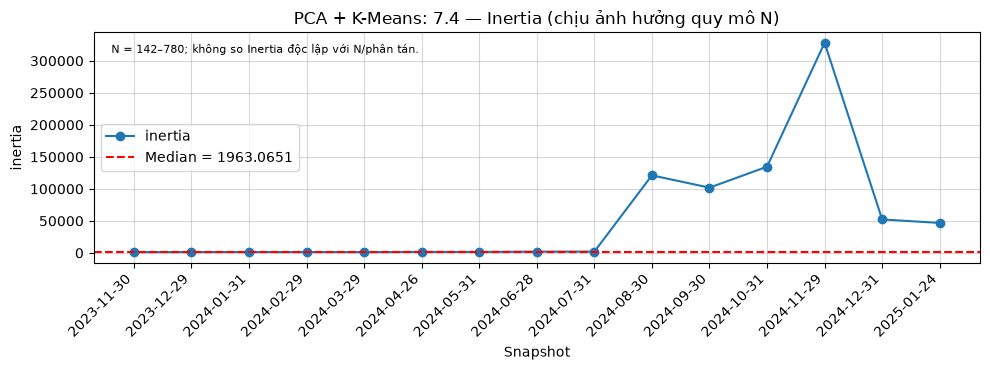

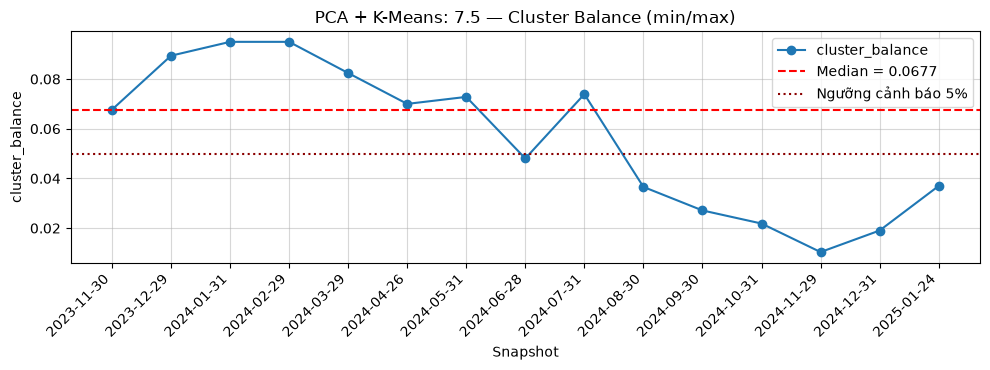

In [5]:
titles = ['7.1 — Silhouette', '7.2 — Davies–Bouldin', '7.3 — Calinski–Harabasz',
          '7.4 — Inertia (chịu ảnh hưởng quy mô N)', '7.5 — Cluster Balance (min/max)']
for metric, title in zip(METRICS, titles):
    fig, ax = plt.subplots(figsize=(10, 3.8))
    y = df_k2[metric].to_numpy(float)
    ax.plot(range(15), y, marker='o', label=metric)
    ax.axhline(np.median(y), color='red', linestyle='--', label=f'Median = {np.median(y):.4f}')
    if metric == 'cluster_balance':
        ax.axhline(.05, color='darkred', linestyle=':', label='Ngưỡng cảnh báo 5%')
    if metric == 'inertia':
        ax.text(.02, .95, f'N = {min(map(lambda s: sum(s.values()), sizes))}–{max(map(lambda s: sum(s.values()), sizes))}; không so Inertia độc lập với N/phân tán.',
                transform=ax.transAxes, va='top', fontsize=8)
    ax.set_xticks(range(15), DEV_DATES, rotation=45, ha='right')
    ax.set(title='PCA + K-Means: ' + title, ylabel=metric, xlabel='Snapshot')
    ax.grid(alpha=.5)
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Biện luận thực chứng và báo cáo nhiệm vụ 7

In [6]:
med = summary_df.set_index('metric')['median']
bad_balance = int(df_k2.cluster_balance.lt(.05).sum())
min_size = min(min(s.values()) for s in sizes)
max_small_size = max(min(s.values()) for s in sizes)
quality_level = 'vượt ngưỡng 0,70' if med.silhouette > .70 else ('vượt ngưỡng 0,50' if med.silhouette > .50 else 'chưa vượt ngưỡng 0,50')
conclusion = f"""# Báo cáo Nhiệm vụ 7 — Chất lượng cụm PCA + K-Means

Nguồn: `m2-task6-pca-kmeans-v1/diagnostics.csv`, chỉ K={K}, 15 snapshot development.

## A — Phán quyết kỹ thuật
Median Silhouette={med.silhouette:.6f} ({quality_level}), DB={med.davies_bouldin:.6f},
CH={med.calinski_harabasz:.4f}, Inertia={med.inertia:.4f}, Balance={med.cluster_balance:.6f}.
Có {bad_balance}/15 tháng Balance <0,05; cụm nhỏ {min_size}–{max_small_size} mã.
Median Balance không thay thế việc kiểm tra từng tháng.

## B — Bản chất cấu trúc quan sát
Hai nhóm có quy mô bất đối xứng. Silhouette cao chỉ chứng minh phân tách trong không gian PCA;
không chứng minh mọi cổ phiếu có hành vi giống nhau hoặc nguyên nhân là dòng tiền/đầu cơ.
Hồ sơ gốc và động lực phân tách được kiểm tra riêng ở nhiệm vụ 8.
Inertia chịu ảnh hưởng N và phân tán, không phải tiêu chí xếp hạng độc lập theo thời gian.

## C — Bàn giao và giới hạn
Bàn giao đủ hai bảng, năm biểu đồ và quality_summary schema 5×7.
Giữ cảnh báo mất cân bằng; không kết luận PCA cải thiện độ ổn định hay giá trị đầu tư.
Không chọn lại K, không fit model, không dùng holdout/portfolio metrics.
"""
display(Markdown(conclusion))
report = conclusion + '\n## Bảng 1\n' + table_md(summary_df.round(6)) + '\n## Bảng 2\n' + table_md(detail_df.round(6))
(REPORT_DIR / 'Bao_cao_M2_Nhiem_vu_7_Chat_luong_cum_PCA_KMeans.md').write_text(report + '\n', encoding='utf-8')

# Báo cáo Nhiệm vụ 7 — Chất lượng cụm PCA + K-Means

Nguồn: `m2-task6-pca-kmeans-v1/diagnostics.csv`, chỉ K=2, 15 snapshot development.

## A — Phán quyết kỹ thuật
Median Silhouette=0.771666 (vượt ngưỡng 0,70), DB=0.515502,
CH=361.5279, Inertia=1963.0651, Balance=0.067669.
Có 7/15 tháng Balance <0,05; cụm nhỏ 8–21 mã.
Median Balance không thay thế việc kiểm tra từng tháng.

## B — Bản chất cấu trúc quan sát
Hai nhóm có quy mô bất đối xứng. Silhouette cao chỉ chứng minh phân tách trong không gian PCA;
không chứng minh mọi cổ phiếu có hành vi giống nhau hoặc nguyên nhân là dòng tiền/đầu cơ.
Hồ sơ gốc và động lực phân tách được kiểm tra riêng ở nhiệm vụ 8.
Inertia chịu ảnh hưởng N và phân tán, không phải tiêu chí xếp hạng độc lập theo thời gian.

## C — Bàn giao và giới hạn
Bàn giao đủ hai bảng, năm biểu đồ và quality_summary schema 5×7.
Giữ cảnh báo mất cân bằng; không kết luận PCA cải thiện độ ổn định hay giá trị đầu tư.
Không chọn lại K, không fit model, không dùng holdout/portfolio metrics.


2744

## Kết luận A/B/C từ số liệu đã chạy

## A — Phán quyết kỹ thuật
Median Silhouette=0.771666 (vượt ngưỡng 0,70), DB=0.515502,
CH=361.5279, Inertia=1963.0651, Balance=0.067669.
Có 7/15 tháng Balance <0,05; cụm nhỏ 8–21 mã.
Median Balance không thay thế việc kiểm tra từng tháng.

## B — Bản chất cấu trúc quan sát
Hai nhóm có quy mô bất đối xứng. Silhouette cao chỉ chứng minh phân tách trong không gian PCA;
không chứng minh mọi cổ phiếu có hành vi giống nhau hoặc nguyên nhân là dòng tiền/đầu cơ.
Hồ sơ gốc và động lực phân tách được kiểm tra riêng ở nhiệm vụ 8.
Inertia chịu ảnh hưởng N và phân tán, không phải tiêu chí xếp hạng độc lập theo thời gian.

## C — Bàn giao và giới hạn
Bàn giao đủ hai bảng, năm biểu đồ và quality_summary schema 5×7.
Giữ cảnh báo mất cân bằng; không kết luận PCA cải thiện độ ổn định hay giá trị đầu tư.
Không chọn lại K, không fit model, không dùng holdout/portfolio metrics.